# Text Extraction — G5: Extracción y procesamiento de texto desde Wikipedia

> **Ejercicio en grupos (Grupo E)** — Dataset: *Text Extraction*. Fuente asignada: **G5 — Extraer datos de Wikipedia** (texto en **inglés**).

Aplicamos el pipeline de **Procesamiento de Lenguaje Natural (NLP)** que pide el enunciado:

1. **Tokenization**, **Stemming**, **Lemmatization** y **Canonización**
2. **Eliminar Stopwords**
3. **Detectar NER** (Named Entity Recognition)
4. **Generar PoS** (Part-of-Speech tagging)
5. **Aplicar BoW y TF-IDF**

**Herramientas:** `requests` (API de Wikipedia), **spaCy** (tokenización, lematización, PoS, NER), **NLTK** (stemming), **scikit-learn** (BoW, TF-IDF).

## 1. Instalación e imports

> En **Google Colab** o un entorno sin estas librerías, la siguiente celda las instala automáticamente. El modelo de spaCy `en_core_web_sm` se descarga la primera vez.

In [1]:
# Instalación robusta (Colab / entorno nuevo). Si ya están, no hace nada.
%pip install -q spacy scikit-learn nltk requests

import re
import unicodedata
import requests
import pandas as pd
import matplotlib.pyplot as plt

import spacy
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Cargar el modelo de spaCy en inglés (se descarga si no existe)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

stemmer = PorterStemmer()
print("spaCy:", spacy.__version__, "| modelo:", nlp.meta["name"])
print("Pipeline spaCy:", nlp.pipe_names)


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


spaCy: 3.8.14 | modelo: core_web_sm
Pipeline spaCy: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 2. Extracción de datos desde Wikipedia (G5)

Extraemos el texto plano de varios artículos **en inglés** usando la **API oficial de MediaWiki** (`action=query&prop=extracts`). Es la forma correcta y estable de obtener datos de Wikipedia (no requiere *scraping* con Selenium).

> Wikipedia exige una cabecera **User-Agent**; sin ella devuelve *403 Forbidden*.

Descargamos **5 artículos relacionados** para tener un *corpus* (varios documentos), necesario para que **BoW** y **TF-IDF** sean significativos.

In [2]:
HEADERS = {"User-Agent": "TextExtractionExercise/1.0 (academico; contacto: estudiante@example.com)"}

def extraer_wikipedia(titulo, idioma="en"):
    '''Devuelve el texto plano de un artículo de Wikipedia via la API de MediaWiki.'''
    url = f"https://{idioma}.wikipedia.org/w/api.php"
    params = {
        "format": "json", "action": "query", "prop": "extracts",
        "explaintext": 1, "redirects": 1, "titles": titulo,
    }
    r = requests.get(url, params=params, headers=HEADERS, timeout=30)
    r.raise_for_status()
    pagina = next(iter(r.json()["query"]["pages"].values()))
    return pagina["title"], pagina.get("extract", "")

TITULOS = ["Artificial intelligence", "Machine learning",
           "Natural language processing", "Computer vision", "Robotics"]

corpus_raw = {}
for t in TITULOS:
    titulo, texto = extraer_wikipedia(t)
    corpus_raw[titulo] = texto
    print(f"  {titulo:32} -> {len(texto):>7,} caracteres")

# Artículo principal sobre el que haremos el pipeline detallado
TITULO_PRINCIPAL = "Artificial intelligence"
texto_principal = corpus_raw[TITULO_PRINCIPAL]
print(f"\nArtículo principal: {TITULO_PRINCIPAL} ({len(texto_principal):,} caracteres)")

  Artificial intelligence          ->  85,147 caracteres


  Machine learning                 ->  58,689 caracteres


  Natural language processing      ->  32,382 caracteres


  Computer vision                  ->  39,055 caracteres


  Robotics                         ->  32,878 caracteres

Artículo principal: Artificial intelligence (85,147 caracteres)


Veamos el inicio del texto crudo extraído:

In [3]:
print(texto_principal[:600], "...")

Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomo ...


## 3. Canonización / Normalización

La **canonización** lleva el texto a una forma estándar para reducir el ruido y que dos formas equivalentes se traten igual. Aplicamos:

- **Normalización Unicode** (NFKC) — unifica caracteres equivalentes.
- **Minúsculas** (*lowercasing*).
- Eliminación de **referencias entre corchetes** (`[1]`, `[note 2]`), **números** y **puntuación**.
- **Colapso de espacios** en blanco.

In [4]:
def canonizar(texto):
    texto = unicodedata.normalize("NFKC", texto)      # normalización Unicode
    texto = texto.lower()                              # minúsculas
    texto = re.sub(r"\[[^\]]*\]", " ", texto)          # quita [1], [note] ...
    texto = re.sub(r"[^a-z\s]", " ", texto)            # solo letras y espacios
    texto = re.sub(r"\s+", " ", texto).strip()         # colapsa espacios
    return texto

texto_canonico = canonizar(texto_principal)
print("ANTES :", texto_principal[:160].replace(chr(10), " "))
print()
print("DESPUÉS:", texto_canonico[:160])

ANTES : Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoni

DESPUÉS: artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning p


## 4. Tokenización

**Tokenizar** = dividir el texto en unidades (*tokens*): palabras y oraciones. Usamos spaCy, que además detecta límites de oración.

In [5]:
# Procesamos con spaCy el texto ORIGINAL (conserva mayúsculas y puntuación,
# necesarias para PoS y NER). Para acelerar, tomamos una porción representativa.
doc = nlp(texto_principal[:20000])

tokens_palabra = [t.text for t in doc if not t.is_space]
oraciones = list(doc.sents)

print(f"Nº de oraciones (en la porción analizada): {len(oraciones)}")
print(f"Nº de tokens: {len(tokens_palabra)}")
print(f"\nPrimeros 25 tokens:\n{tokens_palabra[:25]}")
print(f"\nPrimera oración:\n{oraciones[0].text.strip()}")

Nº de oraciones (en la porción analizada): 140
Nº de tokens: 3646

Primeros 25 tokens:
['Artificial', 'intelligence', '(', 'AI', ')', 'is', 'the', 'capability', 'of', 'computational', 'systems', 'to', 'perform', 'tasks', 'typically', 'associated', 'with', 'human', 'intelligence', ',', 'such', 'as', 'learning', ',', 'reasoning']

Primera oración:
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making.


## 5. Eliminación de Stopwords

Las **stopwords** son palabras muy frecuentes y poco informativas (*the, is, of, and...*). spaCy las marca con `token.is_stop`. También quitamos puntuación y espacios.

In [6]:
tokens_utiles = [t.text.lower() for t in doc
                 if not t.is_stop and not t.is_punct and not t.is_space and t.is_alpha]

print(f"Tokens antes : {len([t for t in doc if not t.is_space])}")
print(f"Tokens después de quitar stopwords/puntuación: {len(tokens_utiles)}")
print(f"\nEjemplo de stopwords detectadas: "
      f"{sorted({t.text.lower() for t in doc if t.is_stop})[:15]}")
print(f"\nTokens útiles (primeros 25):\n{tokens_utiles[:25]}")

Tokens antes : 3646
Tokens después de quitar stopwords/puntuación: 1718

Ejemplo de stopwords detectadas: ["'s", 'a', 'about', 'above', 'after', 'all', 'also', 'among', 'an', 'and', 'another', 'any', 'are', 'as', 'at']

Tokens útiles (primeros 25):
['artificial', 'intelligence', 'ai', 'capability', 'computational', 'systems', 'perform', 'tasks', 'typically', 'associated', 'human', 'intelligence', 'learning', 'reasoning', 'problem', 'solving', 'perception', 'decision', 'making', 'field', 'research', 'engineering', 'mathematics', 'computer', 'science']


## 6. Stemming

El **stemming** recorta la palabra a su *raíz* de forma heurística (puede no ser una palabra real). Usamos el **algoritmo de Porter** (NLTK).

In [7]:
ejemplos = ["learning", "learned", "studies", "studying", "organization",
            "computers", "computing", "happily", "running", "better"]
tabla_stem = pd.DataFrame({
    "palabra": ejemplos,
    "stem (Porter)": [stemmer.stem(w) for w in ejemplos],
})
tabla_stem

,palabra,stem (Porter)
0,learning,learn
1,learned,learn
2,studies,studi
3,studying,studi
4,organization,organ
5,computers,comput
6,computing,comput
7,happily,happili
8,running,run
9,better,better


## 7. Lemmatization

La **lematización** reduce la palabra a su forma de diccionario (*lema*), usando contexto y morfología → siempre produce una palabra real. Comparamos **stemming vs lemmatization**:

In [8]:
comparacion = []
for w in ejemplos:
    lema = nlp(w)[0].lemma_
    comparacion.append({"palabra": w, "stem (Porter)": stemmer.stem(w), "lema (spaCy)": lema})
pd.DataFrame(comparacion)

,palabra,stem (Porter),lema (spaCy)
0,learning,learn,learn
1,learned,learn,learn
2,studies,studi,study
3,studying,studi,study
4,organization,organ,organization
5,computers,comput,computer
6,computing,comput,computing
7,happily,happili,happily
8,running,run,run
9,better,better,well


## 8. PoS — Part-of-Speech tagging

El **etiquetado gramatical** asigna a cada token su categoría (sustantivo, verbo, adjetivo...). spaCy da la etiqueta universal (`pos_`) y la detallada (`tag_`).

,token,lema,PoS,tag,descripción
0,Artificial,artificial,ADJ,JJ,adjective
1,intelligence,intelligence,NOUN,NN,noun
2,(,(,PUNCT,-LRB-,punctuation
3,AI,AI,PROPN,NNP,proper noun
4,),),PUNCT,-RRB-,punctuation
5,is,be,AUX,VBZ,auxiliary
6,the,the,DET,DT,determiner
7,capability,capability,NOUN,NN,noun
8,of,of,ADP,IN,adposition
9,computational,computational,ADJ,JJ,adjective


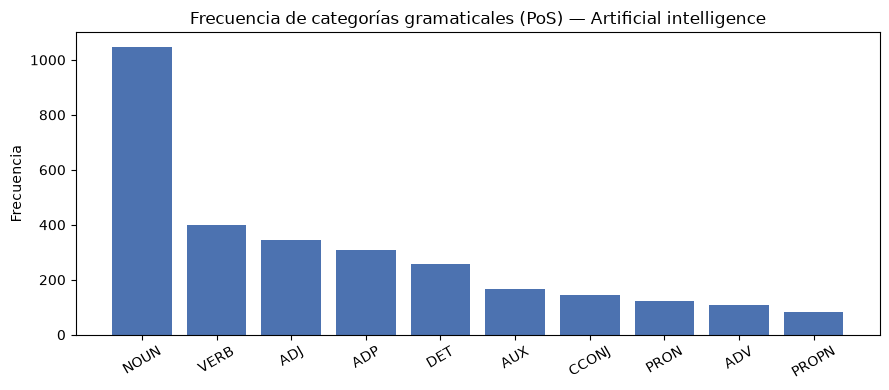

In [9]:
filas = [{"token": t.text, "lema": t.lemma_, "PoS": t.pos_,
          "tag": t.tag_, "descripción": spacy.explain(t.pos_)}
         for t in doc[:15] if not t.is_space]
display(pd.DataFrame(filas))

# Frecuencia de categorías gramaticales
from collections import Counter
pos_freq = Counter(t.pos_ for t in doc if not t.is_space and not t.is_punct)
pos_top = dict(pos_freq.most_common(10))

plt.figure(figsize=(9, 4))
plt.bar(pos_top.keys(), pos_top.values(), color="#4c72b0")
plt.title("Frecuencia de categorías gramaticales (PoS) — " + TITULO_PRINCIPAL)
plt.ylabel("Frecuencia"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 9. NER — Named Entity Recognition

El **reconocimiento de entidades nombradas** detecta y clasifica nombres propios: personas (PERSON), organizaciones (ORG), lugares (GPE), fechas (DATE), etc.

Total de entidades detectadas: 79 (46 únicas)



,entidad,tipo,descripción
0,AI,GPE,"Countries, cities, states"
1,the 2020s,DATE,Absolute or relative dates or periods
2,AI,ORG,"Companies, agencies, institutions, etc."
3,OpenAI,ORG,"Companies, agencies, institutions, etc."
4,DeepMind,PRODUCT,"Objects, vehicles, foods, etc. (not services)"
5,Meta,ORG,"Companies, agencies, institutions, etc."
6,1956,DATE,Absolute or relative dates or periods
7,2012,DATE,Absolute or relative dates or periods
8,2017,DATE,Absolute or relative dates or periods
9,the late 1980s,DATE,Absolute or relative dates or periods


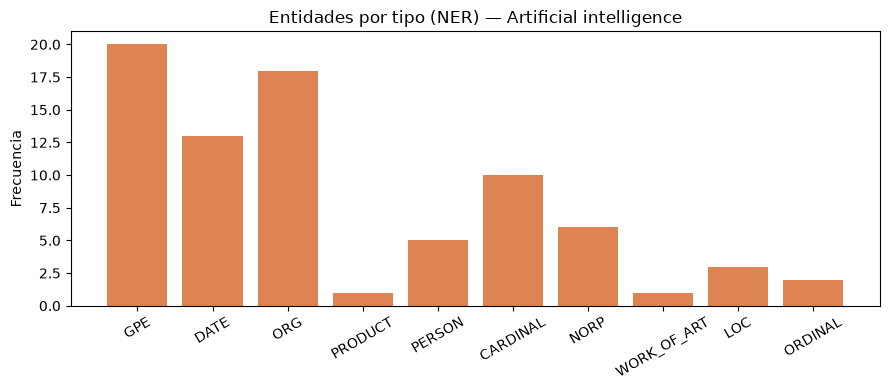

In [10]:
entidades = [{"entidad": ent.text, "tipo": ent.label_,
              "descripción": spacy.explain(ent.label_)} for ent in doc.ents]
df_ent = pd.DataFrame(entidades).drop_duplicates().reset_index(drop=True)
print(f"Total de entidades detectadas: {len(doc.ents)} "
      f"({df_ent.shape[0]} únicas)\n")
display(df_ent.head(20))

# Conteo por tipo de entidad
ner_freq = Counter(ent.label_ for ent in doc.ents)
plt.figure(figsize=(9, 4))
plt.bar(ner_freq.keys(), ner_freq.values(), color="#dd8452")
plt.title("Entidades por tipo (NER) — " + TITULO_PRINCIPAL)
plt.ylabel("Frecuencia"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Visualización de NER** sobre las primeras oraciones (spaCy `displacy`):

In [11]:
from spacy import displacy
from IPython.display import HTML

doc_corto = nlp(" ".join(s.text for s in list(doc.sents)[:4]))
html = displacy.render(doc_corto, style="ent", jupyter=False)
HTML(html)

## 10. BoW — Bag of Words

El modelo **Bolsa de Palabras** representa cada documento como un vector con la **frecuencia** de cada palabra del vocabulario (ignora el orden). Lo aplicamos sobre el **corpus de 5 artículos** ya canonizados.

Documentos: 5 | Tamaño del vocabulario: 1850


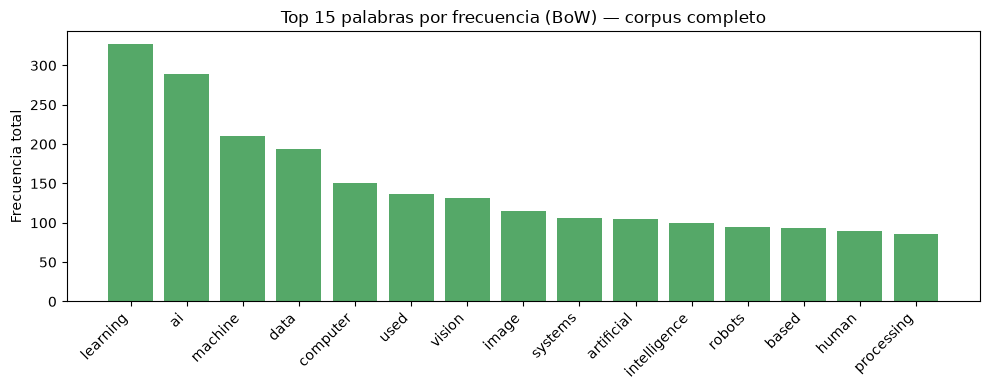


Matriz documento-término (muestra 8 columnas):


,learning,ai,machine,data,computer,used,vision,image
Artificial intelligence,64,245,44,49,18,52,3,7
Machine learning,239,23,131,99,12,31,3,6
Natural language processing,13,8,17,12,10,10,0,4
Computer vision,10,2,17,32,102,18,124,98
Robotics,1,11,1,2,9,26,2,0


In [12]:
# Canonizamos todo el corpus
docs = [canonizar(t) for t in corpus_raw.values()]
nombres_docs = list(corpus_raw.keys())

bow_vec = CountVectorizer(stop_words="english", min_df=2)
X_bow = bow_vec.fit_transform(docs)
vocab = bow_vec.get_feature_names_out()

print(f"Documentos: {X_bow.shape[0]} | Tamaño del vocabulario: {X_bow.shape[1]}")
df_bow = pd.DataFrame(X_bow.toarray(), index=nombres_docs, columns=vocab)

# Top 15 palabras más frecuentes en todo el corpus
top_bow = df_bow.sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 4))
plt.bar(top_bow.index, top_bow.values, color="#55a868")
plt.title("Top 15 palabras por frecuencia (BoW) — corpus completo")
plt.ylabel("Frecuencia total"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

print("\nMatriz documento-término (muestra 8 columnas):")
display(df_bow[top_bow.index[:8]])

## 11. TF-IDF — Term Frequency × Inverse Document Frequency

**TF-IDF** pondera cada palabra por su frecuencia en el documento (**TF**) pero la penaliza si aparece en muchos documentos (**IDF**). Así resalta las palabras **distintivas** de cada artículo.

In [13]:
tfidf_vec = TfidfVectorizer(stop_words="english", min_df=2)
X_tfidf = tfidf_vec.fit_transform(docs)
terminos = tfidf_vec.get_feature_names_out()
df_tfidf = pd.DataFrame(X_tfidf.toarray(), index=nombres_docs, columns=terminos)

print("Palabras más DISTINTIVAS de cada artículo (mayor TF-IDF):\n")
for doc_nombre in nombres_docs:
    top = df_tfidf.loc[doc_nombre].sort_values(ascending=False).head(8)
    print(f"• {doc_nombre}:")
    print("   " + ", ".join(f"{w} ({v:.3f})" for w, v in top.items()))
    print()

Palabras más DISTINTIVAS de cada artículo (mayor TF-IDF):

• Artificial intelligence:
   ai (0.654), intelligence (0.173), learning (0.171), used (0.139), artificial (0.133), data (0.131), human (0.123), machine (0.117)

• Machine learning:
   learning (0.653), machine (0.358), data (0.270), training (0.184), model (0.142), algorithms (0.126), artificial (0.093), set (0.087)

• Natural language processing:
   language (0.383), nlp (0.341), text (0.263), words (0.224), natural (0.202), word (0.180), semantic (0.155), given (0.153)

• Computer vision:
   vision (0.532), image (0.421), computer (0.370), images (0.240), processing (0.156), systems (0.131), isbn (0.117), data (0.116)

• Robotics:
   robots (0.583), robot (0.361), robotics (0.239), control (0.180), used (0.153), robotic (0.124), including (0.100), design (0.099)



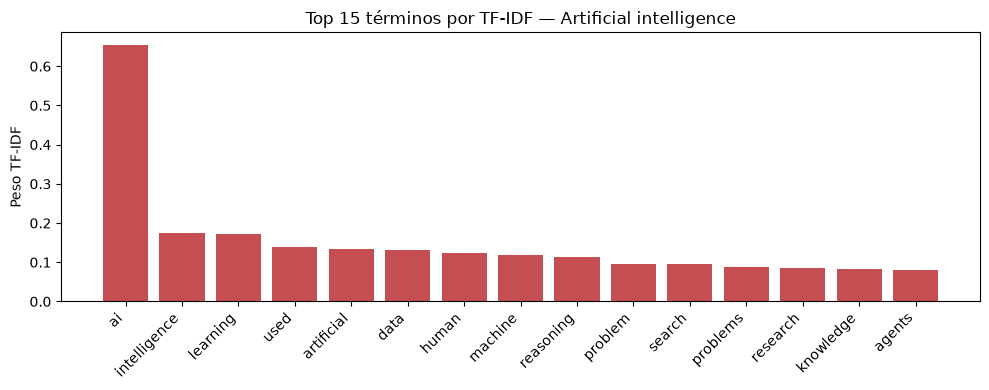

In [14]:
# Comparación visual: top términos TF-IDF del artículo principal
top_tfidf = df_tfidf.loc[TITULO_PRINCIPAL].sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 4))
plt.bar(top_tfidf.index, top_tfidf.values, color="#c44e52")
plt.title("Top 15 términos por TF-IDF — " + TITULO_PRINCIPAL)
plt.ylabel("Peso TF-IDF"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 12. Conclusión

Completamos el ejercicio **G5 — Text Extraction desde Wikipedia** aplicando todo el pipeline de NLP solicitado:

| Paso | Herramienta | Qué hicimos |
|---|---|---|
| **Extracción** | `requests` + API de Wikipedia | 5 artículos en inglés a texto plano |
| **Canonización** | `re` + `unicodedata` | minúsculas, sin puntuación/números, Unicode NFKC |
| **Tokenización** | spaCy | división en oraciones y tokens |
| **Stopwords** | spaCy (`is_stop`) | eliminación de palabras vacías |
| **Stemming** | NLTK (Porter) | raíz heurística de las palabras |
| **Lemmatization** | spaCy | forma de diccionario (lema) |
| **PoS** | spaCy | etiquetado gramatical + frecuencias |
| **NER** | spaCy | entidades (PERSON, ORG, GPE, DATE...) |
| **BoW** | scikit-learn | matriz documento-término por frecuencia |
| **TF-IDF** | scikit-learn | términos distintivos por documento |

**Observaciones:**
- **Stemming vs Lemmatization:** el stemming es más agresivo y puede generar raíces no válidas (*studi*), mientras que la lematización devuelve palabras reales (*study*).
- **BoW vs TF-IDF:** BoW resalta palabras frecuentes globales; **TF-IDF** resalta lo **característico** de cada artículo (p. ej. *image* en *Computer vision*, *robot* en *Robotics*).
- La extracción vía **API** es más robusta y reproducible que el *web scraping* con Selenium.